In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib widget

import spectra.data as data
from spectra.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from spectra.irradiance import Irradiance
from spectra.utilities import ArrayParams
from spectra.normalizeddose import NormalizedDose
from spectra.spectrummodels import (
    ha_model,
    a_b_model,
    a_b_c_model,
    fit_ha_model,
    fit_a_b_model,
    fit_a_b_c_model,
)

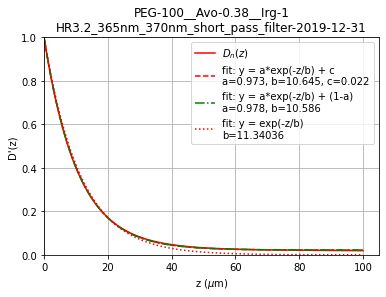

In [2]:
# Create resin
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
avobenzone = ResinConstituentAbsorber(
    data.absorbers['avobenzone_in_PEGDA_2017-04-13'],
    0.38
)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)
resin = Resin(monomers=pegda, absorbers=avobenzone, photoinitiators=irgacure819)

# Source
source = data.sources['HR3.2_365nm_370nm_short_pass_filter-2019-12-31']

# Irradiance
irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=ArrayParams(300, 440, 281))

# z values for normalized dose calculations
z_array_params = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose = NormalizedDose(irradiance=irradiance, z_array_params=z_array_params)

norm_dose.plot(title=(norm_dose.irradiance.resin.name + "\n" + norm_dose.irradiance.source.name));

In [3]:
data.sources

{'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <spectra.sourcespectrum.SourceSpectrum at 0x7f8f599c72d0>,
 'Asiga_405nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x7f8f599c7750>,
 'HR1_385nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x7f8f599c7150>,
 'HR2_385nm_2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7f8f599c74d0>,
 'HR3.2_365nm_370nm_short_pass_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x7f8f48582710>,
 'HR3.2_365nm_no_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x7f8f599b2690>,
 'HR3.3_365nm_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7f8f599b53d0>,
 'HR3.3_365nm_no_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7f8f599ae8d0>,
 'HR3.3_365nm_through_tray_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7f8f599bb050>,
 'HR3.3_365nm_through_tray_no_filter-2020-03-23': <spectra.sourcespectrum.S

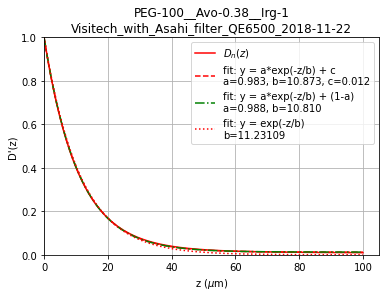

In [4]:
# Source
source2 = data.sources['Visitech_with_Asahi_filter_QE6500_2018-11-22']

# Irradiance
irradiance2 = Irradiance(source=source2, resin=resin, wavelength_array_params=ArrayParams(300, 440, 281))

# z values for normalized dose calculations
z_array_params2 = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose2 = NormalizedDose(irradiance=irradiance2, z_array_params=z_array_params2)

norm_dose2.plot(title=(norm_dose2.irradiance.resin.name + "\n" + norm_dose2.irradiance.source.name));